# Persistent Homology of Möbius Ladder Graphs as Metric Spaces

This notebook experiments with the Vietoris--Rips persistent homology of Möbius ladder graphs \(M_n\), viewed as finite metric spaces using the unweighted graph path-length metric.

For even \(n\), we use the convention
\[
V(M_n)=\{0,1,\dots,n-1\},
\]
with cycle edges \((i,i+1 \bmod n)\) and rung edges \((i,i+n/2 \bmod n)\) for \(0\leq i<n/2\). This convention includes \(M_4\cong K_4\) and \(M_6\cong K_{3,3}\).

The workflow is:

1. Build many Möbius ladder graphs.
2. Compute their shortest-path distance matrices.
3. Pass those matrices to `ripser(..., distance_matrix=True)`.
4. Plot persistence diagrams and barcodes.
5. Summarize persistence statistics across a large collection.

> Note: Ripser computes Vietoris--Rips persistence. Here the input is not a Euclidean point cloud, but a finite metric space given by the graph distance matrix.

In [ ]:
# If needed, uncomment and run this cell once.
# %pip install ripser persim numpy scipy pandas matplotlib ipywidgets networkx

In [1]:
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path

from ripser import ripser
from persim import plot_diagrams

try:
    import networkx as nx
    HAS_NETWORKX = True
except Exception:
    HAS_NETWORKX = False

plt.rcParams["figure.figsize"] = (7, 5)

## 1. Construct Möbius ladder graphs and graph metrics

The function below returns both the edge set and a sparse adjacency matrix. We then compute the all-pairs shortest-path matrix, which is the graph path-length metric.

In [2]:
def mobius_ladder_edges(n: int):
    """Return undirected edges of the Möbius ladder M_n.

    Parameters
    ----------
    n : int
        Even number of vertices. The convention here allows n=4.

    Returns
    -------
    edges : list[tuple[int, int]]
        Unique undirected edges.
    """
    if n % 2 != 0 or n < 4:
        raise ValueError("n must be an even integer at least 4")

    edges = set()

    # Cycle edges
    for i in range(n):
        a, b = i, (i + 1) % n
        edges.add(tuple(sorted((a, b))))

    # Rung/opposite edges
    half = n // 2
    for i in range(half):
        a, b = i, i + half
        edges.add(tuple(sorted((a, b))))

    return sorted(edges)


def mobius_ladder_adjacency(n: int):
    """Sparse adjacency matrix for M_n."""
    edges = mobius_ladder_edges(n)
    rows, cols = [], []
    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])
    data = np.ones(len(rows), dtype=float)
    return csr_matrix((data, (rows, cols)), shape=(n, n))


def mobius_ladder_distance_matrix(n: int):
    """All-pairs unweighted shortest-path distance matrix for M_n."""
    A = mobius_ladder_adjacency(n)
    D = shortest_path(A, directed=False, unweighted=True)
    return np.asarray(D, dtype=float)


def graph_diameter_from_distance_matrix(D):
    """Diameter of a finite metric space represented by a distance matrix."""
    return int(np.nanmax(D[np.isfinite(D)]))


# Quick sanity checks
for n in [4, 6, 8, 10]:
    edges = mobius_ladder_edges(n)
    D = mobius_ladder_distance_matrix(n)
    print(f"M_{n}: vertices={n}, edges={len(edges)}, expected edges={3*n//2}, diameter={graph_diameter_from_distance_matrix(D)}")
    assert len(edges) == 3*n//2
    assert np.allclose(D, D.T)
    assert np.allclose(np.diag(D), 0)

M_4: vertices=4, edges=6, expected edges=6, diameter=1
M_6: vertices=6, edges=9, expected edges=9, diameter=2
M_8: vertices=8, edges=12, expected edges=12, diameter=2
M_10: vertices=10, edges=15, expected edges=15, diameter=3


## 2. Optional graph visualization

The drawing is only for intuition. Persistent homology below uses the path metric, not the drawing geometry.

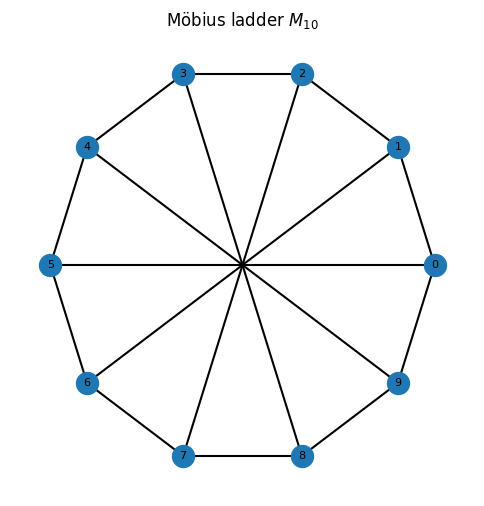

In [31]:
def draw_mobius_ladder(n: int, ax=None, layout="circle"):
    """Draw M_n using NetworkX if available."""
    if not HAS_NETWORKX:
        raise ImportError("networkx is not installed. Run `%pip install networkx` or skip this section.")

    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_edges_from(mobius_ladder_edges(n))

    if layout == "circle":
        pos = nx.circular_layout(G)
    elif layout == "spring":
        pos = nx.spring_layout(G, seed=0)
    else:
        raise ValueError("layout must be 'circle' or 'spring'")

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=250)
    nx.draw_networkx_edges(G, pos, ax=ax, width=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
    ax.set_title(f"Möbius ladder $M_{{{n}}}$")
    ax.axis("off")
    return ax


draw_mobius_ladder(10);

## 3. Compute Vietoris--Rips persistence with Ripser

Because `D` is already a distance matrix, we call

```python
ripser(D, distance_matrix=True, maxdim=maxdim, coeff=coeff)
```

For larger graphs, start with `maxdim=1`. Computing \(H_2\) and above can become expensive because Vietoris--Rips complexes may contain many high-dimensional simplices.

In [37]:
def compute_mobius_persistence(n: int, maxdim: int = 2, coeff: int = 2, thresh=None, do_cocycles=False):
    """Compute persistent homology of M_n with the path-length metric."""
    D = mobius_ladder_distance_matrix(n)
    if thresh is None:
        thresh = graph_diameter_from_distance_matrix(D)

    t0 = time.perf_counter()
    result = ripser(
        D,
        distance_matrix=True,
        maxdim=maxdim,
        coeff=coeff,
        thresh=thresh,
        do_cocycles=do_cocycles,
    )
    elapsed = time.perf_counter() - t0

    result["n"] = n
    result["diameter"] = graph_diameter_from_distance_matrix(D)
    result["thresh"] = thresh
    result["maxdim"] = maxdim
    result["coeff"] = coeff
    result["elapsed_seconds"] = elapsed
    return result


example = compute_mobius_persistence(34, maxdim=5)
print(f"Computed M_{example['n']} in {example['elapsed_seconds']:.3f}s")
for dim, dgm in enumerate(example["dgms"]):
    print(f"H_{dim}: {len(dgm)} intervals")
    print(dgm[:10])

Computed M_34 in 0.452s
H_0: 34 intervals
[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]
H_1: 18 intervals
[[1. 2.]
 [1. 2.]
 [1. 2.]
 [1. 2.]
 [1. 2.]
 [1. 2.]
 [1. 2.]
 [1. 2.]
 [1. 2.]
 [1. 2.]]
H_2: 1 intervals
[[6. 7.]]
H_3: 2 intervals
[[6. 7.]
 [6. 7.]]
H_4: 0 intervals
[]
H_5: 1 intervals
[[7. 8.]]


## 4. Plot persistence diagrams and barcodes

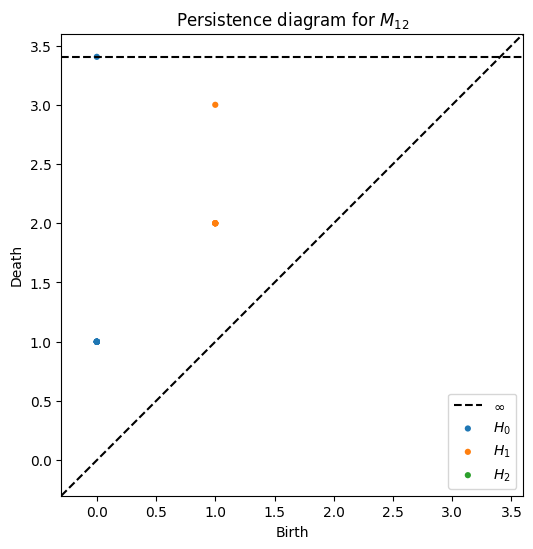

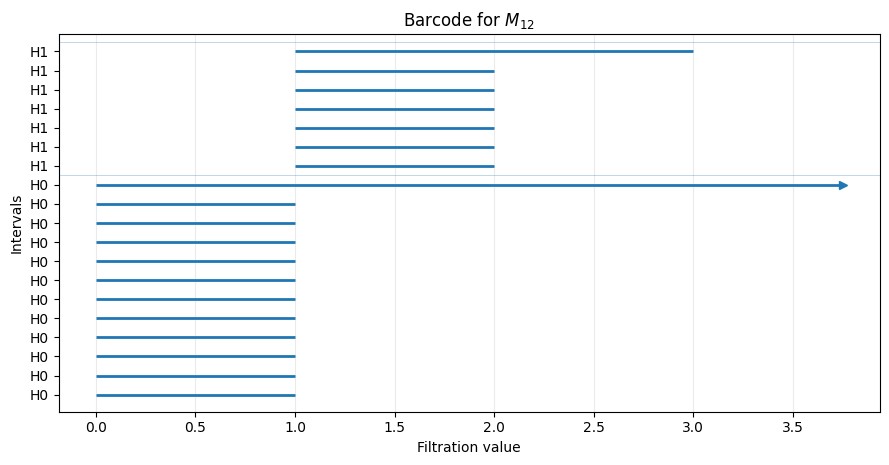

In [5]:
def plot_persistence_diagram(result, title=None):
    """Plot persistence diagrams from a Ripser result dictionary."""
    if title is None:
        title = f"Persistence diagram for $M_{{{result['n']}}}$"
    plt.figure(figsize=(6, 6))
    plot_diagrams(result["dgms"], show=False)
    plt.title(title)
    plt.show()


def plot_barcode(result, dims=None, sort_by="birth", title=None, inf_extension=0.25):
    """Plot a barcode for selected homology dimensions.

    Infinite deaths are displayed slightly beyond the largest finite death.
    """
    dgms = result["dgms"]
    if dims is None:
        dims = list(range(len(dgms)))

    finite_deaths = []
    for dgm in dgms:
        if len(dgm):
            finite_deaths.extend(dgm[np.isfinite(dgm[:, 1]), 1].tolist())
    max_finite = max(finite_deaths) if finite_deaths else 1.0
    inf_value = max_finite + inf_extension * max(1.0, max_finite)

    fig, ax = plt.subplots(figsize=(9, max(3, 0.25 * sum(len(dgms[d]) for d in dims))))
    y = 0
    yticks = []
    yticklabels = []

    for dim in dims:
        intervals = np.array(dgms[dim], dtype=float)
        if len(intervals) == 0:
            continue

        if sort_by == "birth":
            order = np.lexsort((intervals[:, 1], intervals[:, 0]))
        elif sort_by == "persistence":
            deaths_for_sort = intervals[:, 1].copy()
            deaths_for_sort[~np.isfinite(deaths_for_sort)] = inf_value
            pers = deaths_for_sort - intervals[:, 0]
            order = np.argsort(-pers)
        else:
            order = np.arange(len(intervals))

        for idx in order:
            birth, death = intervals[idx]
            death_display = inf_value if not np.isfinite(death) else death
            ax.hlines(y, birth, death_display, linewidth=2)
            if not np.isfinite(death):
                ax.plot(death_display, y, marker=">", markersize=6)
            yticks.append(y)
            yticklabels.append(f"H{dim}")
            y += 1

        ax.axhline(y - 0.5, linewidth=0.5, alpha=0.4)

    ax.set_xlabel("Filtration value")
    ax.set_ylabel("Intervals")
    if len(yticks) <= 60:
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)
    else:
        ax.set_yticks([])
    if title is None:
        title = f"Barcode for $M_{{{result['n']}}}$"
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_persistence_diagram(example)
plot_barcode(example, dims=[0, 1, 2])

## 5. Batch computation for a large collection

Adjust `N_VALUES`, `MAXDIM`, and `COEFF` as desired. Results are cached to disk with `pickle`, so you can avoid recomputing large batches.

Suggested starting points:

- `maxdim=1` for many graphs, e.g. up to \(n=200\) or beyond.
- `maxdim=2` for moderate sizes.
- Use `thresh` below the diameter if you only care about early-scale features.

In [20]:
N_VALUES = list(range(4, 82, 2))  # all even n from 4 to 80
MAXDIM = 3
COEFF = 2
THRESH = None  # None means use the graph diameter for each graph
CACHE_FILE = Path(f"mobius_ladder_persistence_maxdim{MAXDIM}_coeff{COEFF}.pkl")


def batch_compute_mobius(ns, maxdim=1, coeff=2, thresh=None, cache_file=None, force=False):
    """Compute persistence for many M_n and optionally cache results."""
    if cache_file is not None:
        cache_file = Path(cache_file)
        if cache_file.exists() and not force:
            with cache_file.open("rb") as f:
                return pickle.load(f)

    results = {}
    for n in ns:
        print(f"Computing M_{n} ...", end=" ")
        try:
            res = compute_mobius_persistence(n, maxdim=maxdim, coeff=coeff, thresh=thresh)
            results[n] = res
            print(f"done in {res['elapsed_seconds']:.3f}s")
        except Exception as e:
            print(f"FAILED: {e}")
            results[n] = {"n": n, "error": repr(e)}

    if cache_file is not None:
        with cache_file.open("wb") as f:
            pickle.dump(results, f)
    return results


results = batch_compute_mobius(
    N_VALUES,
    maxdim=MAXDIM,
    coeff=COEFF,
    thresh=THRESH,
    cache_file=CACHE_FILE,
    force=False,
)

## 6. Summarize persistence across the collection

The summary below records, for each \(M_n\) and each dimension, the number of intervals, number of finite intervals, maximum persistence, and total persistence.

In [21]:
def diagram_stats(dgm):
    """Summary statistics for one persistence diagram."""
    dgm = np.asarray(dgm, dtype=float)
    if len(dgm) == 0:
        return {
            "intervals": 0,
            "finite_intervals": 0,
            "infinite_intervals": 0,
            "max_persistence": 0.0,
            "total_persistence": 0.0,
            "mean_persistence": 0.0,
        }

    finite = np.isfinite(dgm[:, 1])
    pers = dgm[finite, 1] - dgm[finite, 0]
    return {
        "intervals": int(len(dgm)),
        "finite_intervals": int(np.sum(finite)),
        "infinite_intervals": int(np.sum(~finite)),
        "max_persistence": float(np.max(pers)) if len(pers) else 0.0,
        "total_persistence": float(np.sum(pers)) if len(pers) else 0.0,
        "mean_persistence": float(np.mean(pers)) if len(pers) else 0.0,
    }


def summarize_results(results):
    rows = []
    for n, res in results.items():
        if "error" in res:
            rows.append({"n": n, "dimension": None, "error": res["error"]})
            continue
        for dim, dgm in enumerate(res["dgms"]):
            row = {
                "n": n,
                "dimension": dim,
                "diameter": res["diameter"],
                "elapsed_seconds": res["elapsed_seconds"],
                "coeff": res["coeff"],
                "maxdim": res["maxdim"],
            }
            row.update(diagram_stats(dgm))
            rows.append(row)
    return pd.DataFrame(rows)


summary = summarize_results(results)
summary.head(12)

,n,dimension,diameter,elapsed_seconds,coeff,maxdim,intervals,finite_intervals,infinite_intervals,max_persistence,total_persistence,mean_persistence,error
0,4,0.0,1.0,0.001298,2.0,3.0,4.0,3.0,1.0,1.0,3.0,1.0,NaN
1,4,1.0,1.0,0.001298,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,4,2.0,1.0,0.001298,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,4,3.0,1.0,0.001298,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError('n must be an even integer at least...
5,6,0.0,2.0,0.000072,2.0,3.0,6.0,5.0,1.0,1.0,5.0,1.0,NaN
6,6,1.0,2.0,0.000072,2.0,3.0,4.0,4.0,0.0,1.0,4.0,1.0,NaN
7,6,2.0,2.0,0.000072,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
8,6,3.0,2.0,0.000072,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
9,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError('n must be an even integer at least...


In [ ]:
# Save summary table for later use
summary.to_csv("mobius_ladder_persistence_summary.csv", index=False)
summary.tail(12)

## 7. Plot trends across \(n\)

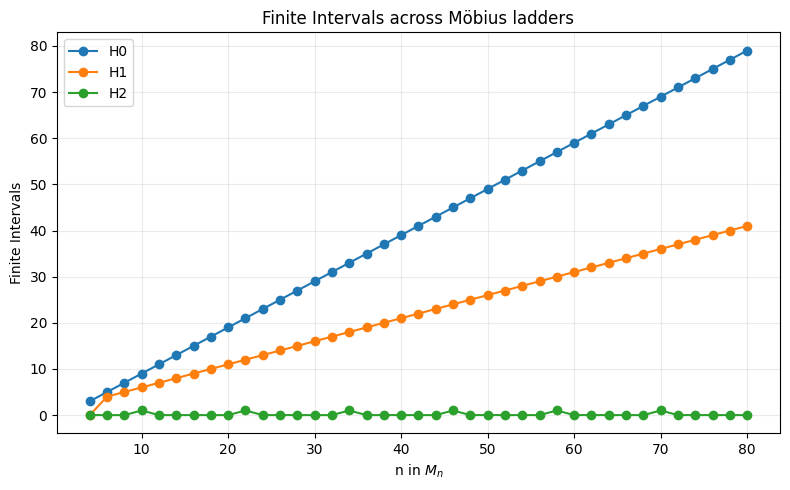

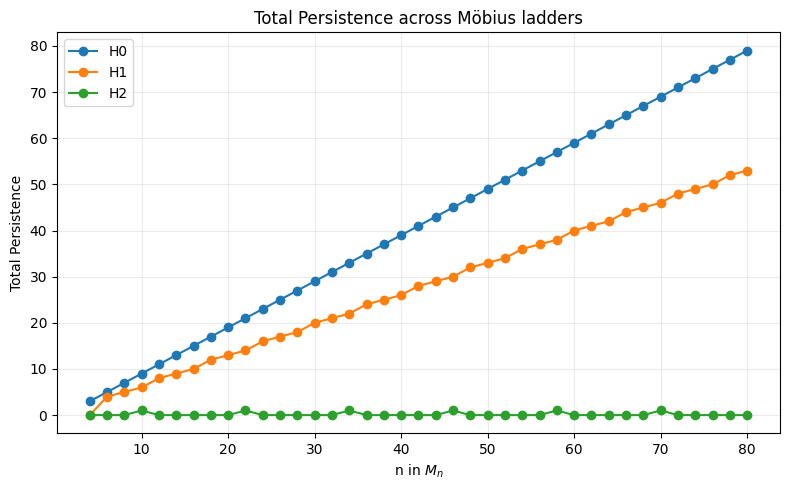

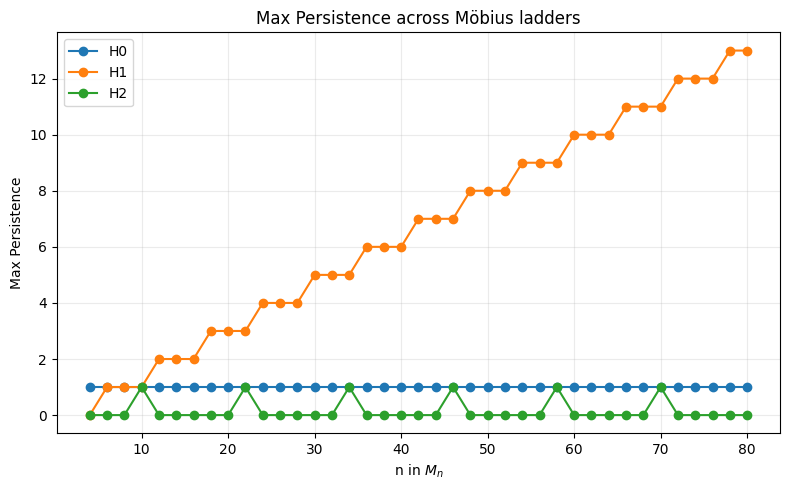

In [22]:
def plot_summary_trends(summary, dimensions=None, y="total_persistence"):
    if dimensions is None:
        dimensions = sorted(d for d in summary["dimension"].dropna().unique())

    fig, ax = plt.subplots(figsize=(8, 5))
    for dim in dimensions:
        sub = summary[summary["dimension"] == dim].sort_values("n")
        ax.plot(sub["n"], sub[y], marker="o", label=f"H{int(dim)}")
    ax.set_xlabel("n in $M_n$")
    ax.set_ylabel(y.replace("_", " ").title())
    ax.set_title(f"{y.replace('_', ' ').title()} across Möbius ladders")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_summary_trends(summary, dimensions=[0, 1, 2], y="finite_intervals")
plot_summary_trends(summary, dimensions=[0, 1, 2], y="total_persistence")
plot_summary_trends(summary, dimensions=[0, 1, 2], y="max_persistence")

## 8. Inspect one graph from the batch

Change `SELECTED_N` to any even value in `N_VALUES`.

M_24: diameter=6, elapsed=0.001s
H_0: 24 intervals
H_1: 13 intervals
H_2: 0 intervals


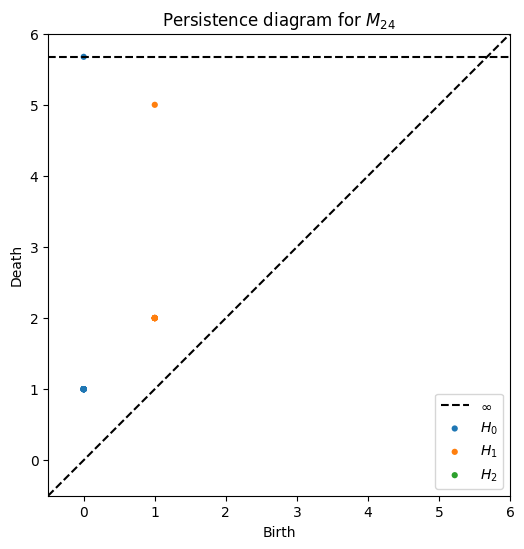

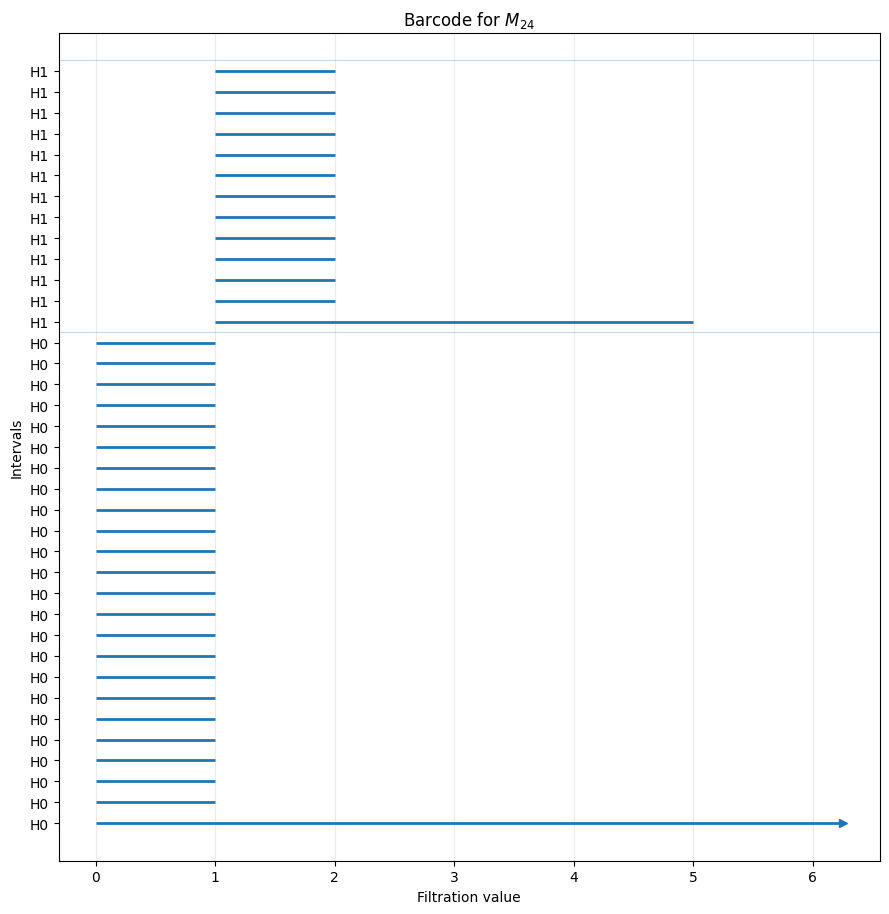

In [9]:
SELECTED_N = 24
selected = results[SELECTED_N]

print(f"M_{SELECTED_N}: diameter={selected['diameter']}, elapsed={selected['elapsed_seconds']:.3f}s")
for dim, dgm in enumerate(selected["dgms"]):
    print(f"H_{dim}: {len(dgm)} intervals")

plot_persistence_diagram(selected)
plot_barcode(selected, dims=list(range(MAXDIM + 1)), sort_by="persistence")

## 9. Optional interactive explorer

If `ipywidgets` is installed and enabled, this cell creates a dropdown to inspect diagrams and barcodes without editing code cells.

In [10]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    n_widget = widgets.Dropdown(options=sorted(results.keys()), value=sorted(results.keys())[0], description="n")
    dims_widget = widgets.SelectMultiple(
        options=list(range(MAXDIM + 1)),
        value=tuple(range(MAXDIM + 1)),
        description="dims",
    )
    out = widgets.Output()

    def update(change=None):
        with out:
            clear_output(wait=True)
            n = n_widget.value
            dims = list(dims_widget.value)
            res = results[n]
            if "error" in res:
                print(res["error"])
                return
            print(f"M_{n}: diameter={res['diameter']}, elapsed={res['elapsed_seconds']:.3f}s")
            plot_persistence_diagram(res)
            plot_barcode(res, dims=dims, sort_by="persistence")

    n_widget.observe(update, names="value")
    dims_widget.observe(update, names="value")
    display(widgets.HBox([n_widget, dims_widget]), out)
    update()
except Exception as e:
    print("Interactive widgets are unavailable:", e)

Output()

## 10. Export selected diagrams as data frames

This is useful if you want to analyze the persistence intervals outside Python.

In [ ]:
def diagrams_to_dataframe(result):
    rows = []
    for dim, dgm in enumerate(result["dgms"]):
        for birth, death in dgm:
            rows.append({
                "n": result["n"],
                "dimension": dim,
                "birth": float(birth),
                "death": float(death),
                "persistence": float(death - birth) if np.isfinite(death) else np.inf,
            })
    return pd.DataFrame(rows)


all_intervals = pd.concat(
    [diagrams_to_dataframe(res) for res in results.values() if "error" not in res],
    ignore_index=True,
)
all_intervals.to_csv("mobius_ladder_persistence_intervals.csv", index=False)
all_intervals.head()

## 11. Ideas for further experiments

- Compare \(n\equiv 0\pmod 4\) and \(n\equiv 2\pmod 4\), since these have different bipartiteness behavior.
- Study stability under edge deletion, edge subdivision, or weighted rungs.
- Compare Möbius ladders with ordinary ladder/prism graphs using the same path metric.
- Run with different coefficient fields, e.g. `COEFF = 3` or `COEFF = 5`.
- Compute representative cocycles with `do_cocycles=True` for selected small graphs.